# <center>Laboratorium 12<br>Metody Numeryczne</center>    


In [18]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import scipy as sp
import scipy.integrate as ing

In [19]:
"""Funkcje pomocnicze"""

"""Średni kwadrat odległości pzybliżenia od oryginału"""

def sr_kw(y_orig:np.array,y_comprised:np.array):
    dif=y_comprised-y_orig
    return np.sum(dif**2)/np.size(y_orig)

""" Zwraca wektor wartości y_n taki że f(t_orig)=f(t_sample)=y_n lecz o rozmiarze t_sample"""

def fit(y_orig,t_orig,t_sample):
    yn=np.linspace(t_sample[0],t_sample[-1],np.size(t_sample))
    ind=0
    for i in range(np.size(t_orig)-1):
     b=y_orig[i]
     dt=t_orig[i+1]-t_orig[i]
     a=(y_orig[i+1]-b)/dt
     d=(a*t_orig[i]+b)-y_orig[i]
     while ind<np.size(t_sample) and t_orig[i+1]>=t_sample[ind] :
        yn[ind]=t_sample[ind]*a+b-d
        ind+=1
    return yn


def solve_euler(fun: callable, t_span: np.array, y0: np.array):
    ''' 
    Funkcja umożliwiająca rozwiązanie układu równań różniczkowych z wykorzystaniem metody Eulera w przód.
    
    Parameters:
    fun: Prawa strona równania. Podana funkcja musi mieć postać fun(t, y). 
    Tutaj t jest skalarem i istnieją dwie opcje dla ndarray y: Może mieć kształt (n,); wtedy fun musi zwrócić array_like z kształtem (n,). 
    Alternatywnie może mieć kształt (n, k); wtedy fun musi zwrócić tablicę typu array_like z kształtem (n, k), tj. każda kolumna odpowiada jednej kolumnie w y. 
    t_span: wektor czasu dla którego ma zostać rozwiązane równanie
    y0: warunke początkowy równanai o wymiarze (n,)
    Results:
    (np.array): macierz o wymiarze (n,m) zawierająca w wkolumnach kolejne rozwiązania fun w czasie t_span.  

    '''
    l=np.size(y0)
    t=np.size(t_span)
    new=np.zeros([t,l])  
    new[0]=y0
    h=t_span[1]-t_span[0]

    for ind in range(1,t):
      f=fun(t_span[ind-1],new[ind-1])
      for i in range(l):
          f[i]*=h
      new[ind]=new[ind-1]+f
    return new

Instrukcja:  
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi z komentarzami.

**Cel zajęć:** Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania równań różniczkowych
zwyczajnych. Będziemy rozpatrywać równania różniczkowe postaci
$$\dot{x}(t) = f(x(t), t)$$
gdzie:

$x(t) \in \mathbb{R}^n$,

$t \ge 0$ 


z warunkiem początkowym $x(0) = x0$

Jest to tak zwany problem początkowy (problem Cauchy’ego) dla równań różniczkowych zwyczajnych.

**Zadanie 1.**  
Za pomocą funkcji [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp) przy wykorzystaniu dwóch metod **RK45** i **RK23** rozwiąż wszystkie równania z poprzedniego laboratorium i porównaj wyniki z zaimplementowaną metodą Eulera w przód.

In [20]:
"""zad 2 plot"""
def zad2p(end):
    def f(t,x):
        return (x+t)/(x-t)

    f_real = lambda t: t + np.sqrt(1 + 2 * t**2)
    t=np.linspace(0,end,1000)
    x0=np.array([1])
    y=f_real(t)


    s45=ing.solve_ivp(f, (t[0],t[-1]), x0, method='RK45',max_step=2*(t[1]-t[0]))
    y45=s45.y.T
    t45=s45.t
    yn45=fit(y45,t45,t)
    d45=sr_kw(y,yn45)

    s23=ing.solve_ivp(f, (t[0],t[-1]), x0, method='RK23',max_step=2*(t[1]-t[0]))
    y23=s23.y.T
    t23=s23.t
    yn23=fit(y23,t23,t)
    d23=sr_kw(y,yn23)

    seul=solve_euler(f,t,x0)
    seul=seul.reshape(-1)
    deul=sr_kw(y,seul)



    """plot"""
    plt.figure()
    plt.grid()
    plt.plot(t,y,'r')
    plt.plot(t45,y45,'b')
    plt.plot(t23,y23,'k')
    plt.plot(t,seul,'m')


In [21]:
"""zad 2 bar"""
def zad2b(end,x_step=1):
    def f(t,x):
        return (x+t)/(x-t)

    f_real = lambda t: t + np.sqrt(1 + 2 * t**2)
    t=np.linspace(0,end,1000)
    x0=np.array([1])
    y=f_real(t)


    s45=ing.solve_ivp(f, (t[0],t[-1]), x0, method='RK45',max_step=x_step*(t[1]-t[0]))
    y45=s45.y.T
    t45=s45.t
    yn45=fit(y45,t45,t)
    d45=sr_kw(y,yn45)

    s23=ing.solve_ivp(f, (t[0],t[-1]), x0, method='RK23',max_step=x_step*(t[1]-t[0]))
    y23=s23.y.T
    t23=s23.t
    yn23=fit(y23,t23,t)
    d23=sr_kw(y,yn23)

    seul=solve_euler(f,t,x0)
    seul=seul.reshape(-1)
    deul=sr_kw(y,seul)


    """bar"""
    fig,ax=plt.subplots()
    ax.bar([0,1,2],[deul,d23,d45])
    plt.semilogy()
    title='Średni kwadrat odległości przybliżenia od rozwiązania [0,'+str(end)+'] i max kroku '+str(x_step)+'x h Eulera'
    ax.set_title(title)
    x = np.arange(3)
    ax.set_xticks(x)
    ax.set_xticklabels(['euler','R23','R45'])

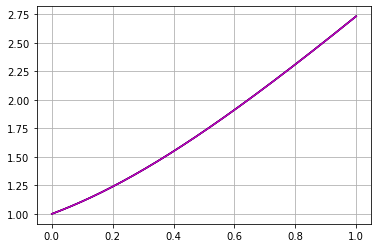

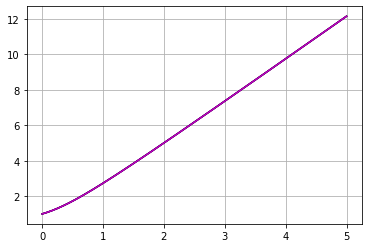

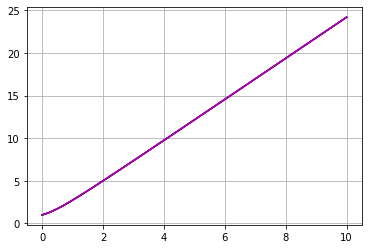

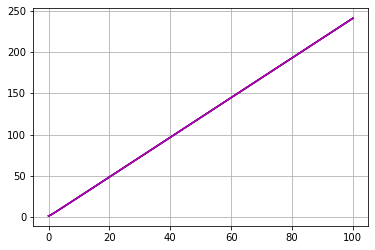

In [22]:
zad2p(1)
zad2p(5)
zad2p(10)
zad2p(100)

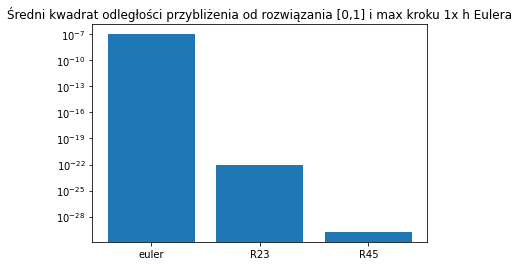

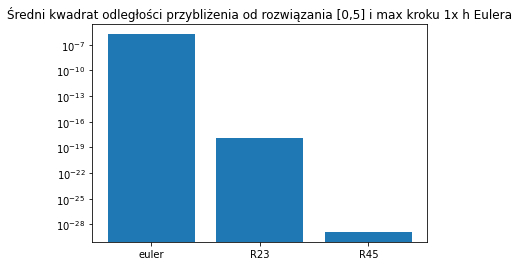

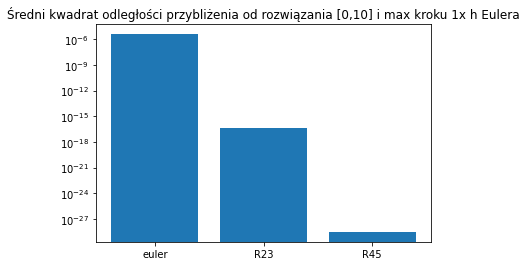

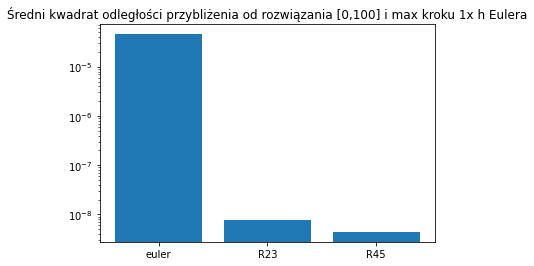

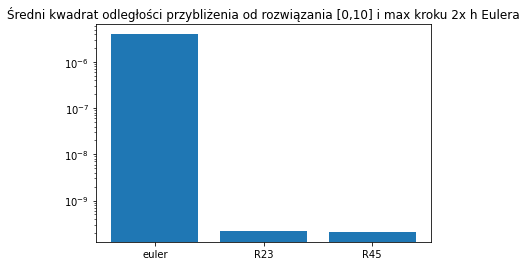

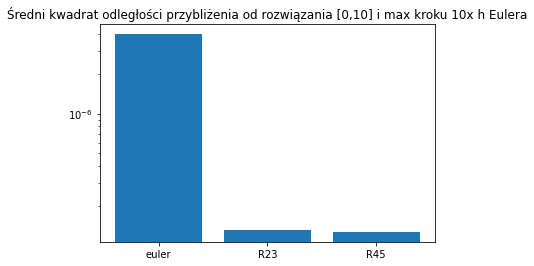

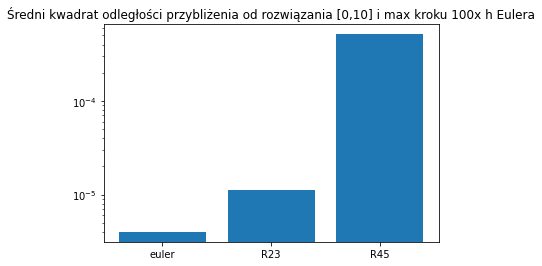

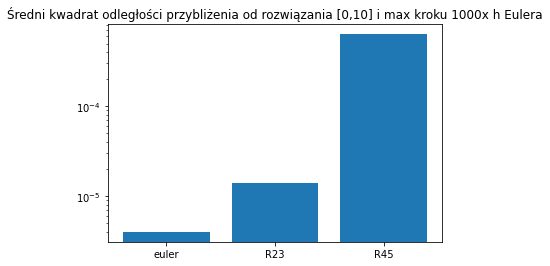

In [23]:

zad2b(1)
zad2b(5)
zad2b(10)
zad2b(100)
zad2b(10,2)
zad2b(10,10)
zad2b(10,100)
zad2b(10,1000)


Najlepszą metodą jest R45 potem R23 a na końcu Euler.
Po zwiększeniu parametru maksymalnego kroku (z początkowego równego h w Eulerze) dokładność R23 znacząco się zwiększyła nieomal zrównując się z R45, a następnie przeganiając tę metodę przy maksymalnym kroku 100*h. Wtedy też Euler stawał się dokłądniejszy od pozostałych. Należy pamiętać że owa mniejsz adokładność wiąże się z mniejszą ilością iteracji niż u Eulera a tym samym mniejszą ilością iteracji.
Jednak przy R metodach rozsądnie jest pamiętać o korekcji parametru max_step, szczególnie w R45.



In [24]:
"""zad 3 function"""
def f(t :np.array,y :np.array):
  yn=[0.0,0.0,0.0,0.0]
  yn[0]=y[2]
  yn[1]=y[3]
  yn[2]=-y[0]/(y[0]**2+y[1]**2)**1.5
  yn[3]=-y[1]/(y[0]**2+y[1]**2)**1.5
  return yn

def zad3(end,x_step=1):

  t=np.linspace(0,end,1000)
  x0=np.array([1,0,0,1])
  y=[np.cos(t),np.sin(t),-np.sin(t),np.cos(t)]


  s45=ing.solve_ivp(f, (t[0],t[-1]), x0,vectorized=True, method='RK45',max_step=x_step*(t[1]-t[0]))
  y45=s45.y
  t45=s45.t
  yn450=fit(y45[0],t45,t)
  yn451=fit(y45[1],t45,t)
  yn452=fit(y45[2],t45,t)
  yn453=fit(y45[3],t45,t)
  d45=np.ones([1,4])
  d45=d45.reshape(-1)
  d45[0]=sr_kw(y[0],yn450)
  d45[1]=sr_kw(y[1],yn451)
  d45[2]=sr_kw(y[2],yn452)
  d45[3]=sr_kw(y[3],yn453)

  s23=ing.solve_ivp(f, (t[0],t[-1]), x0,vectorized=True, method='RK23',max_step=x_step*(t[1]-t[0]))
  y23=s23.y
  t23=s23.t
  yn230=fit(y23[0],t23,t)
  yn231=fit(y23[1],t23,t)
  yn232=fit(y23[2],t23,t)
  yn233=fit(y23[3],t23,t)
  d23=np.ones([1,4])
  d23=d23.reshape(-1)
  d23[0]=sr_kw(y[0],yn230)
  d23[1]=sr_kw(y[1],yn231)
  d23[2]=sr_kw(y[2],yn232)
  d23[3]=sr_kw(y[3],yn233)

  seul=solve_euler(f,t,x0)
  seuln=np.ones([4,int(np.size(seul)/4)])
  for i in range(int(np.size(seul)/4)):
      for j in range(4):
        seuln[j][i]=seul[i][j]
  deul=np.ones([1,4])
  deul=deul.reshape(-1)
  deul[0]=sr_kw(y[0],seuln[0])
  deul[1]=sr_kw(y[1],seuln[1])
  deul[2]=sr_kw(y[2],seuln[2])
  deul[3]=sr_kw(y[3],seuln[3])
  
  return [[y,seuln,y23,y45],[t,t23,t45]],[deul,d23,d45]


In [25]:
def zad3b(max_step=1):
    labe=['5','10','30','50','100']
    l=0.2
    fig, (ax1, ax2,ax3,ax4) = plt.subplots(1,4)
    fig.suptitle('max step = h*'+str(max_step))
    x = np.arange(1/l)
    ax1.set_title('y[0]')
    d5=zad3(5,max_step)[1]
    d10=zad3(10,max_step)[1]
    d30=zad3(30,max_step)[1]
    d50=zad3(50,max_step)[1]
    d100=zad3(100,max_step)[1]
    k=0
    n=0
    fr=[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]]
    ax1.bar(x-0.2,fr,l,label='Euler')
    n=1
    ax1.bar(x,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R23')
    n=2
    ax1.bar(x+0.2,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R45')
    ax1.semilogy()
    ax1.legend()
    ax1.set_xticks(x)
    ax1.set_xticklabels(labe)

    ax2.set_title('y[1]')
    d5=zad3(5,max_step)[1]
    d10=zad3(10,max_step)[1]
    d30=zad3(30,max_step)[1]
    d50=zad3(50,max_step)[1]
    d100=zad3(100,max_step)[1]
    k=1
    n=0
    ax2.bar(x-0.2,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='Euler')
    n=1
    ax2.bar(x,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R23')
    n=2
    ax2.bar(x+0.2,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R45')
    ax2.semilogy()
    ax2.set_xticks(x)
    ax2.set_xticklabels(labe)
    
    ax3.set_title('y[0]')
    d5=zad3(5,max_step)[1]
    d10=zad3(10,max_step)[1]
    d30=zad3(30,max_step)[1]
    d50=zad3(50,max_step)[1]
    d100=zad3(100,max_step)[1]
    k=2
    n=0
    ax3.bar(x-0.2,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='Euler')
    n=1
    ax3.bar(x,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R23')
    n=2
    ax3.bar(x+0.2,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R45')
    ax3.semilogy()
    ax3.set_xticks(x)
    ax3.set_xticklabels(labe)
    
    ax4.set_title('y[0]')
    d5=zad3(5,max_step)[1]
    d10=zad3(10,max_step)[1]
    d30=zad3(30,max_step)[1]
    d50=zad3(50,max_step)[1]
    d100=zad3(100,max_step)[1]
    k=3
    n=0
    ax4.bar(x-0.2,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='Euler')
    n=1
    ax4.bar(x,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R23')
    n=2
    ax4.bar(x+0.2,[d5[n][k],d10[n][k],d30[n][k],d50[n][k],d100[n][k]],l,label='R45')
    ax4.semilogy()
    ax4.set_xticks(x)
    ax4.set_xticklabels(labe)

In [10]:
def zad3p(end,max_step=1):
    plt.figure()
    plt.suptitle('max krok = h*'+str(max_step))
    [[y,seuln,y23,y45],[t,t23,t45]],err=zad3(end,max_step)
    n=0
    plt.subplot(4,1,1)
    plt.title('y['+str(n)+']')
    plt.plot(t,y[n],t,seuln[n],t23,y23[n],t45,y45[n])
    plt.legend(['orig','euler','r23','r45'])
    [[y,seuln,y23,y45],[t,t23,t45]],err=zad3(end,max_step)
    n=1
    plt.subplot(4,1,2)
    plt.title('y['+str(n)+']')
    plt.plot(t,y[n],t,seuln[n],t23,y23[n],t45,y45[n])

    [[y,seuln,y23,y45],[t,t23,t45]],err=zad3(end,max_step)
    n=2
    plt.subplot(4,1,3)
    plt.title('y['+str(n)+']')
    plt.plot(t,y[n],t,seuln[n],t23,y23[n],t45,y45[n])
    [[y,seuln,y23,y45],[t,t23,t45]],err=zad3(end,max_step)
    n=3
    plt.subplot(4,1,4)
    plt.title('y['+str(n)+']')
    plt.plot(t,y[n],t,seuln[n],t23,y23[n],t45,y45[n])


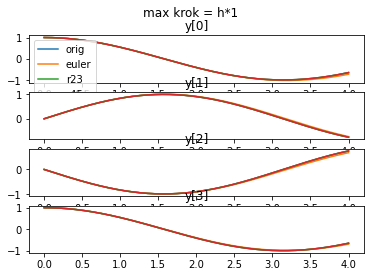

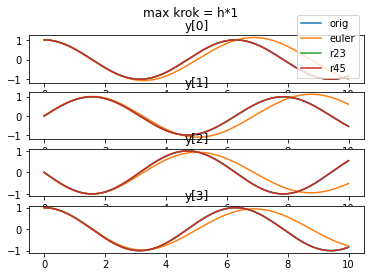

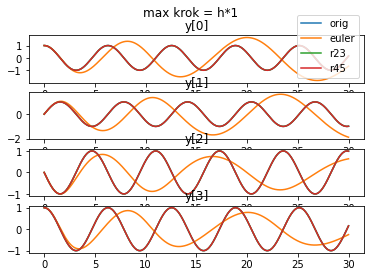

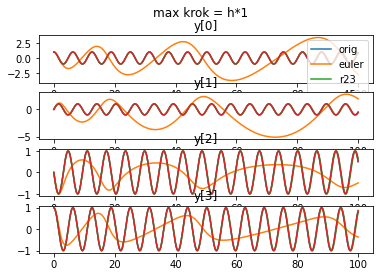

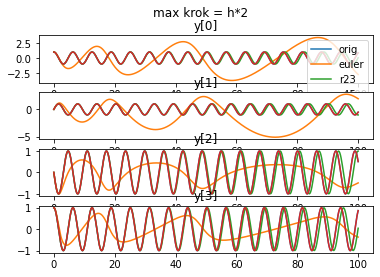

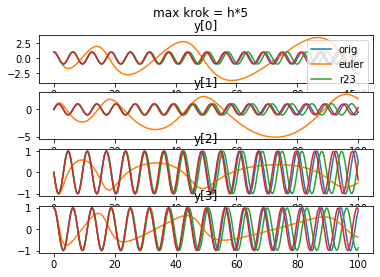

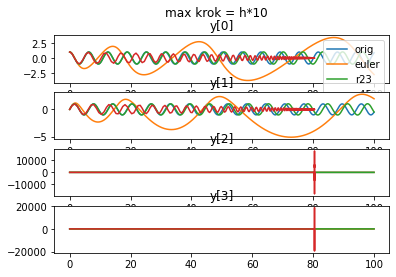

In [11]:
zad3p(4)
zad3p(10)
zad3p(30)
zad3p(100)
zad3p(100,2)
zad3p(100,5)
zad3p(100,10)


Widać jak delikatność wszystkich algorytmów na sinusoidy, Euler nadaje się do przybliżania zaledwie połowy okresu, potem błędy są za duże.
R23 i R45 radzą sobie dobrze tak długo jak maksymalny krok jest nie większy niż 1/10. POtem zaczynają odchodzić od rozwiązania a w szczególności R45.

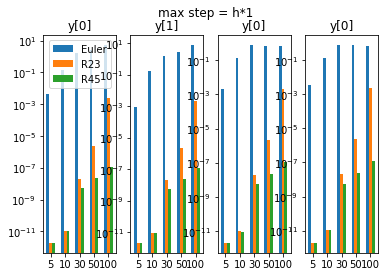

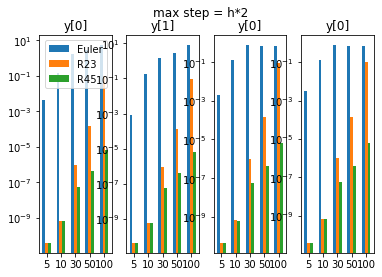

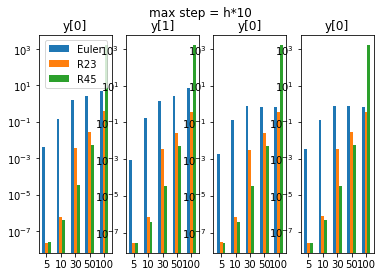

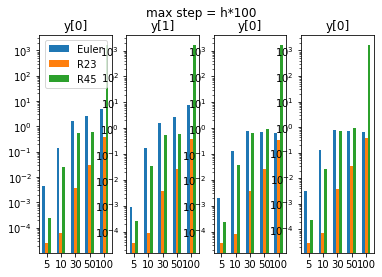

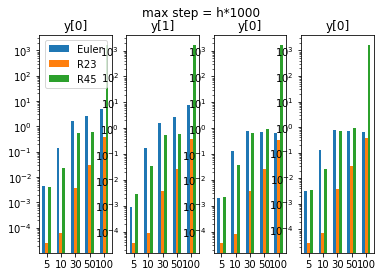

In [12]:
zad3b(1)
zad3b(2)
zad3b(10)
zad3b(100)
zad3b(1000)

Im mniejszy maksymalny krok tym lepiej, przy czym najbardziej służy on R45, a R23 o wiele lepiej radzi sobie ze swobodą. 

In [13]:
"""zad 4"""


def fa(t,y):
    A=np.array([[-667, 333],[666, -334]])
    return A@y

x0 = np.array([0, 3])

def zad4(end,x_step=1):

  t=np.linspace(0,end,10000)

  plt.figure()
  s45=ing.solve_ivp(fa, (t[0],t[-1]), x0,vectorized=True, method='RK45',max_step=x_step*(t[1]-t[0]))
  y45=s45.y
  t45=s45.t
  plt.plot(t45,y45[0])
  plt.plot(t45,y45[1])


  s23=ing.solve_ivp(fa, (t[0],t[-1]), x0,vectorized=True, method='RK23',max_step=x_step*(t[1]-t[0]))
  y23=s23.y
  t23=s23.t
  plt.plot(t23,y23[0])
  plt.plot(t23,y23[1])

  seul=solve_euler(fa,t,x0)
  seuln=np.ones([2,int(np.size(seul)/2)])
  for i in range(int(np.size(seul)/2)):
      for j in range(2):
       seuln[j][i]=seul[i][j]
  plt.plot(t,seuln[0])
  plt.legend(['Euler x0','Euler x1'])
  plt.plot(t,seuln[1])
  plt.legend(['R45 x0','R45 x1','R23 x0','R23 x1','Euler x0','Euler x1'])
  plt.title('[0,'+str(end)+'] z max krokiem h*'+str(x_step))

<ipython-input-13-4db533417f66>:6: RuntimeWarning: overflow encountered in matmul
  return A@y
<ipython-input-19-267f54edcaa4>:49: RuntimeWarning: invalid value encountered in add
  new[ind]=new[ind-1]+f


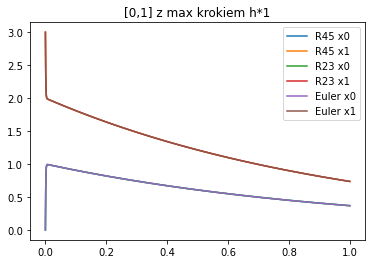

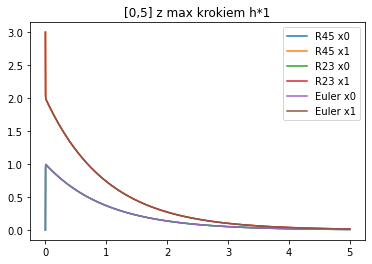

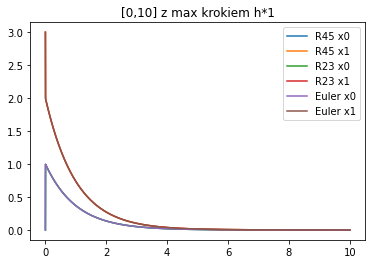

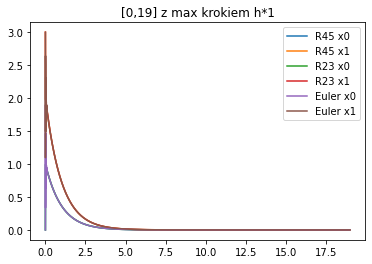

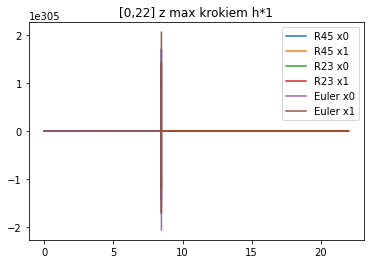

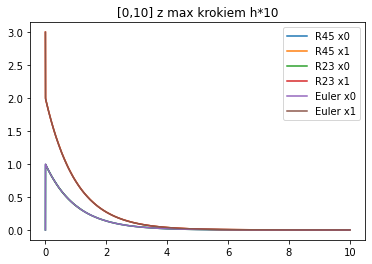

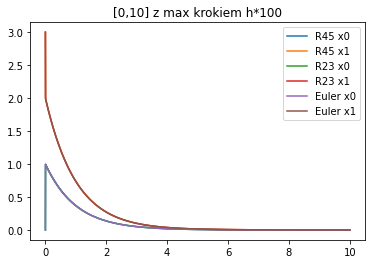

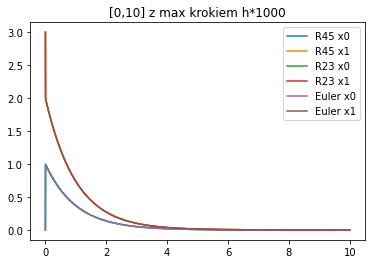

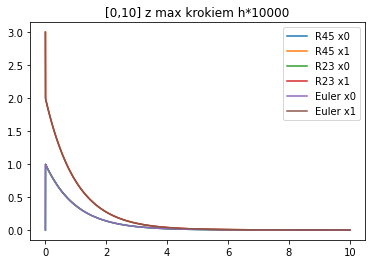

In [33]:
zad4(1)
zad4(5)
zad4(10)
zad4(19)
zad4(22)
zad4(10,10)
zad4(10,100)
zad4(10,1000)
zad4(10,10000)

Żaden R-algorytm nie skorzystał nierozsądnie z danej mu swobody, wygląda na to że dla odpowiednio małego przedziału niezależnie od kroku działają one równie dobrze, tak samo Euler. Dla wszystkich problemy jednak zaczynają się dla zbyt dużego przedziału, tutaj już od 0 do 19,20. 

Najwyra

In [15]:
def odl(start,stop):
    return np.sqrt((start[0]-stop[0])**2+(start[0]-stop[0])**2)

In [16]:
"""zad 5"""

def orb(t :np.array,y :np.array):
 yn=[0.0,0.0,0.0,0.0]
 u=0.012277471
 up=1-u
 D1=((y[0]+u)**2+y[2]**2)**(3/2)
 D2=((y[0]-up)**2+y[2]**2)**(3/2)
 yn[0]=y[1]
 yn[1]=y[0]+2*y[3]-up*(y[0]+u)/D1-u*(y[0]-up)/D2
 yn[2]=y[3]
 yn[3]=y[2]-2*y[1]-up*y[2]/D1-u*y[2]/D2
 return yn


def zad5(loops,x_step=1):
  T = 17.0652165601579625588917206249
  t=np.linspace(0,T*loops,100000)
  x0=np.array([0.994,0,0,-2.00158510637908252240537862224])


  s45=ing.solve_ivp(orb, (t[0],t[-1]), x0,vectorized=True, method='RK45',max_step=x_step*(t[1]-t[0]))
  y45=s45.y
  t45=s45.t


  s23=ing.solve_ivp(orb, (t[0],t[-1]), x0,vectorized=True, method='RK23',max_step=x_step*(t[1]-t[0]))
  y23=s23.y
  t23=s23.t

  seul=solve_euler(orb,t,x0)
  seuln=np.ones([4,int(np.size(seul)/4)])
  for i in range(int(np.size(seul)/4)):
      for j in range(4):
        seuln[j][i]=seul[i][j]
  plt.figure()
  plt.plot(seuln[0],seuln[2])
  plt.plot(y23[0],y23[2])
  plt.plot(y45[0],y45[2])
  plt.legend(['Euler','R23','R45'])
  plt.title(str(loops)+' pętla max krok h*'+str(x_step))
  
  deu=odl([seuln[0][0],seuln[2][0]],[seuln[0][-1],seuln[2][-1]])
  d23=odl([y23[0][0],y23[2][0]],[y23[0][-1],y23[2][-1]])
  d45=odl([y45[0][0],y45[2][0]],[y45[0][-1],y45[2][-1]])
  err=[deu,d23,d45]
  plt.figure()
  fig,ax=plt.subplots()
  ax.bar([1,2,3],err)
  ax.semilogy()
  ax.set_xticks([1,2,3])
  ax.set_xticklabels(['Euler','R23','R45'])


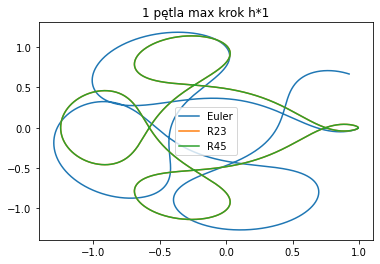

<Figure size 432x288 with 0 Axes>

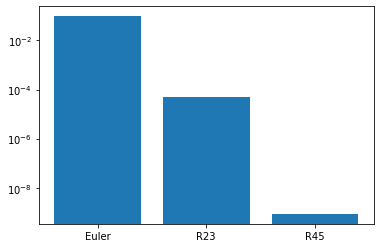

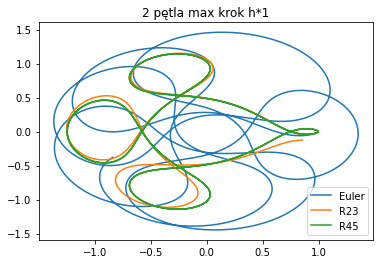

<Figure size 432x288 with 0 Axes>

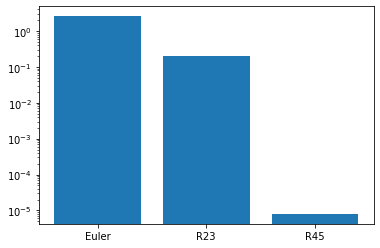

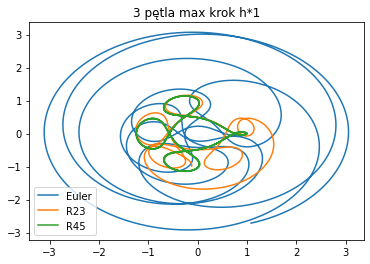

<Figure size 432x288 with 0 Axes>

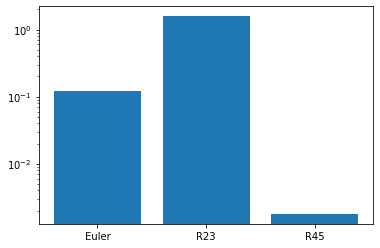

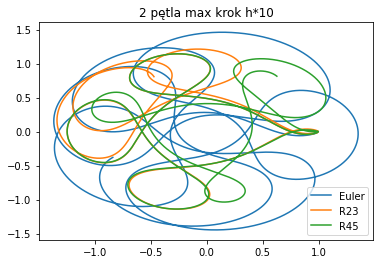

<Figure size 432x288 with 0 Axes>

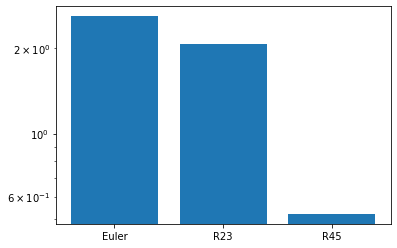

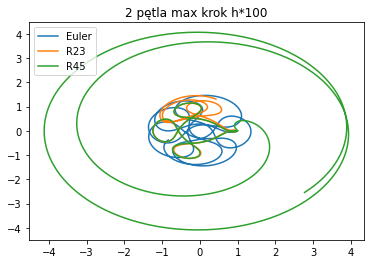

<Figure size 432x288 with 0 Axes>

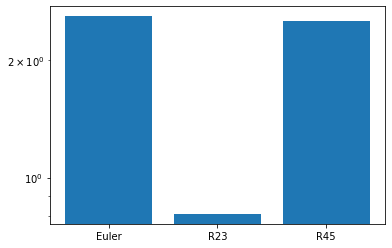

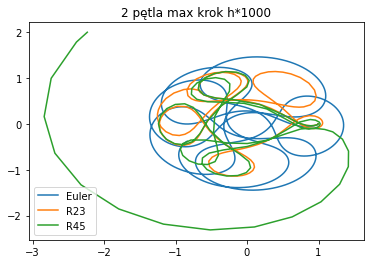

<Figure size 432x288 with 0 Axes>

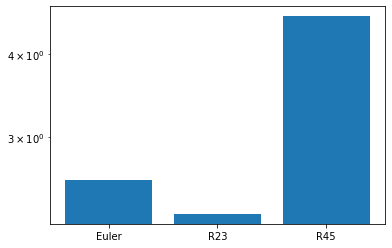

In [17]:
zad5(1)
zad5(2)
zad5(3)
zad5(2,10)
zad5(2,100)
zad5(2,1000)

R45 ponownie udowadnia że lepiej nie dawać mu za dużo swobody zbyt dużym maksymalnym krokiem, który na ostatnim wykresie widać gołym okiem.
R23 za to całkiem rozsądnie korzysta z danej mu swobody choć nie jest tak dobry jak ujarzmiony małym maksymanym krokiem R45.
Zatem tak najbezpiczniej jest korzystać z R23, za to jeśli znamy bezpieczny maksymalny krok warto skorzystać z R45.

im więcej punktów w t-span tym dokładność winna być większa, tspan winno stanowić o dokładności Eulera, 2 okresy do orbity bądź trochę po

**Bibliografia**

1. J. C. Butcher. Numerical Methods for Ordinary Differential Equations. John Wiley and Sons, Ltd., 2003.
2. Z. Fortuna, B. Macukow, and J. Wąsowski. Metody numeryczne. WNT Warszawa, 1982.
3. E. Hairer, S.P. Nørsett, and G. Wanner. Solving Ordinary Differential Equations: I Nonstiff problems. Springer, 2 edition, 2000.
4. W. Mitkowski. Równania macierzowe i ich zastosowania. Wydawnictwa AGH, Kraków,2 edition, 2007.
5. A. Ralston. Wstęp do analizy numerycznej. PWN, Warszawa, 1965.
6. L. F. Shampine, I. Gladwell, and S. Thompson. Solving ODEs with MATLAB. Cambridge University Press, 2003.
7. Stoer, J., Burlirsch, R., 1980: Wstêp do metod numerycznych, tom 2. PWN Warszawa.
